In [1]:
%load_ext autoreload
%autoreload 2

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from formulations.dynamics import m as dyn_model
from formulations.cost import m as cost_model
from pysim import build, solve, rollout, cost_along, types

In [8]:
dyn = build(dyn_model)
cost = build(cost_model)
p = types.RobotParams.default_hand_tuned()
target = types.MpcTarget.goto(types.Vec2(2000.0, 0.0))
cfg = types.SolverConfig(horizon=50)

In [9]:
r = solve(dyn, cost, np.zeros(4), np.zeros(cfg.horizon + 1), target, p, cfg=cfg)
print(f"iters={r.iters} converged={r.converged} cost={r.final_cost:.2f}")
print(f"last state: {r.states[-1]}")

iters=8 converged=True cost=23047.63
last state: [2024.79111073    0.          131.35958776    0.        ]


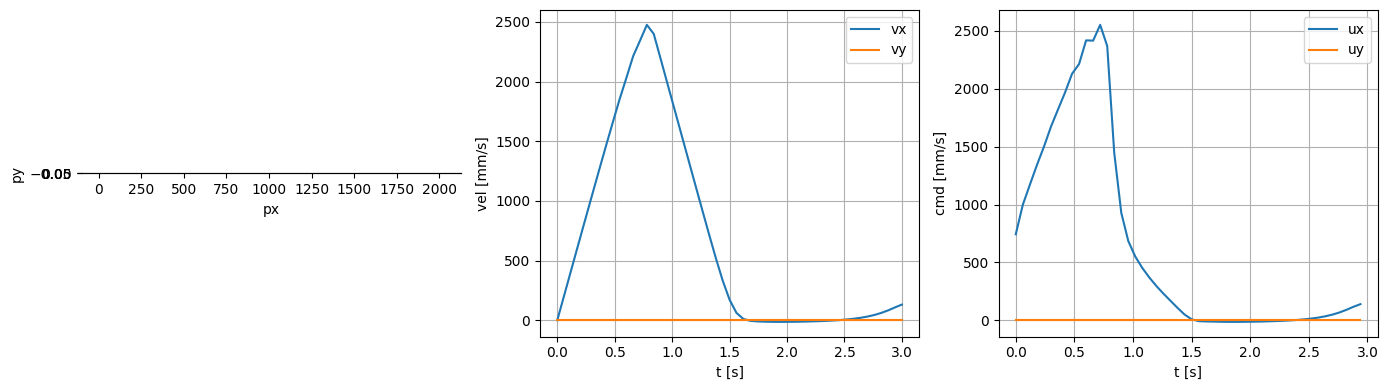

In [10]:
t = np.arange(cfg.horizon + 1) * cfg.dt
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].plot(r.states[:, 0], r.states[:, 1], "-o", ms=3)
ax[0].plot(target.p.x, target.p.y, "r*", ms=15)
ax[0].set_aspect("equal"); ax[0].grid(); ax[0].set_xlabel("px"); ax[0].set_ylabel("py")
ax[1].plot(t, r.states[:, 2], label="vx")
ax[1].plot(t, r.states[:, 3], label="vy")
ax[1].legend(); ax[1].grid(); ax[1].set_xlabel("t [s]"); ax[1].set_ylabel("vel [mm/s]")
ax[2].plot(t[:-1], r.controls[:, 0], label="ux")
ax[2].plot(t[:-1], r.controls[:, 1], label="uy")
ax[2].legend(); ax[2].grid(); ax[2].set_xlabel("t [s]"); ax[2].set_ylabel("cmd [mm/s]")
plt.tight_layout(); plt.show()

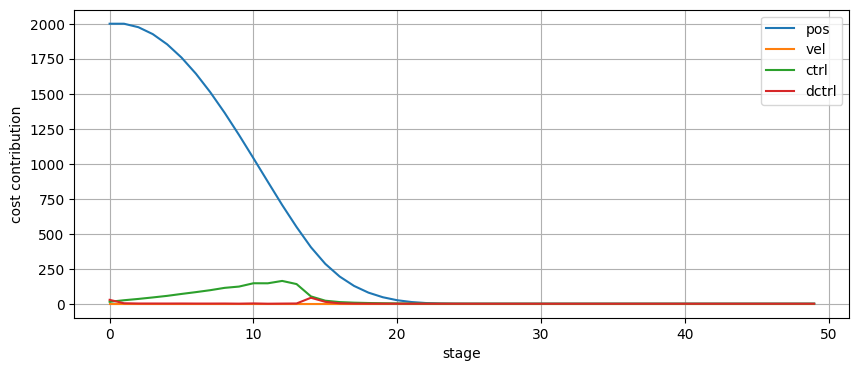

In [6]:
total, per_stage = cost_along(cost, r.states, r.controls, target)
stages = per_stage[:-1]
fig, ax = plt.subplots(figsize=(10, 4))
for term in ["pos", "vel", "ctrl", "dctrl"]:
    ax.plot([s["k"] for s in stages], [s[term] for s in stages], label=term)
ax.legend(); ax.grid(); ax.set_xlabel("stage"); ax.set_ylabel("cost contribution")
plt.show()